<a href="https://colab.research.google.com/github/sbrgothub/Turkey_Online_Retail_New/blob/main/Customer_Rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/ecommerce_customer_behavior_dataset_v2.csv")
df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


# date format conversion (object - date)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

# Discount %

In [ ]:
df['Discount_%']=(df['Discount_Amount']/df['Total_Amount'])*100

                                              ML

In [ ]:
df['Customer_Rating'].value_counts()

,count
Customer_Rating,
5,6260
4,5863
3,2658
2,1487
1,781


In [ ]:
x=df[['Session_Duration_Minutes','Age','Pages_Viewed','Total_Amount']]

In [ ]:
def rater(x):
  if x in (1, 2):
    return 1      # Bad
  elif x == 3:
    return 2      # Neutral
  else:
    return 3      # Good


In [ ]:
df['Customer_Rating']=df['Customer_Rating'].apply(rater)

In [ ]:
y=df['Customer_Rating']

In [ ]:
bins = pd.cut(df['Pages_Viewed'], bins=4)
df.groupby(bins)['Customer_Rating'].value_counts()
bins.value_counts()

/tmp/ipython-input-2645616181.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(bins)['Customer_Rating'].value_counts()


,count
Pages_Viewed,
"(5.25, 9.5]",8936
"(9.5, 13.75]",6743
"(0.983, 5.25]",1016
"(13.75, 18.0]",354


In [ ]:
def pager(x):
  if x > 0.983 and x <= 5.25:
    return '0.983 : 5.25'
  elif x > 5.25 and x <= 9.5:
    return '5.25 : 9.5'
  elif x > 9.5 and x <= 13.75:
    return '9.5 : 13.75'
  else:
    return '13.75 : 18.0'

In [ ]:
x['Pages_Viewed']=x['Pages_Viewed'].apply(pager)

/tmp/ipython-input-2275475809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Pages_Viewed']=x['Pages_Viewed'].apply(pager)


In [ ]:
bins = pd.cut(df['Session_Duration_Minutes'], bins=8)
df.groupby(bins)['Customer_Rating'].value_counts()
bins.value_counts()

/tmp/ipython-input-2483892604.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(bins)['Customer_Rating'].value_counts()


,count
Session_Duration_Minutes,
"(12.25, 15.0]",6638
"(15.0, 17.75]",3689
"(9.5, 12.25]",3408
"(17.75, 20.5]",2256
"(6.75, 9.5]",647
"(20.5, 23.25]",326
"(3.978, 6.75]",64
"(23.25, 26.0]",21


In [ ]:
def session(x):
  if x > 3.978 and x <= 6.75:
    return '3.978 : 6.75'
  elif x > 6.75 and x <= 9.5:
    return '6.75 : 9.5'
  elif x > 9.5 and x <= 12.25:
    return '9.5 : 12.25'
  elif x > 12.25 and x <= 15.0:
    return '12.25 : 15.0'
  elif x > 15.0 and x <= 17.75:
    return '15.0 : 17.75'
  elif x > 17.75 and x <= 20.5:
    return '17.75 : 20.5'
  elif x > 20.5 and x <= 23.25:
    return '20.5 : 23.25'
  else:
    return '23.25 : 26.0'

In [ ]:
x['Session_Duration_Minutes']=x['Session_Duration_Minutes'].apply(session)

/tmp/ipython-input-277456522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Session_Duration_Minutes']=x['Session_Duration_Minutes'].apply(session)


In [ ]:
bins=pd.cut(df['Total_Amount'],bins=12)
df.groupby(bins)['Customer_Rating'].value_counts()

/tmp/ipython-input-798218233.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(bins)['Customer_Rating'].value_counts()


Total_Amount          Customer_Rating
(-31.636, 3160.03]    3                  10844
                      2                   2385
                      1                   2038
(3160.03, 6313.85]    3                    829
                      2                    172
                      1                    137
(6313.85, 9467.67]    3                    239
                      1                     50
                      2                     48
(9467.67, 12621.49]   3                    111
                      2                     23
                      1                     20
(12621.49, 15775.31]  3                     50
                      1                     13
                      2                     13
(15775.31, 18929.13]  3                     28
                      1                      7
                      2                      7
(18929.13, 22082.95]  3                     13
                      2                      4
                      1                      1
(22082.95, 25236.77]  2                      3
                      3                      3
                      1                      2
(25236.77, 28390.59]  2                      2
                      3                      2
                      1                      0
(28390.59, 31544.41]  3                      2
                      2                      1
                      1                      0
(31544.41, 34698.23]  3                      1
                      1                      0
                      2                      0
(34698.23, 37852.05]  3                      1
                      1                      0
                      2                      0
Name: count, dtype: int64

In [ ]:
def amount(x):
  if x > -31.636 and x <= 3160.03:
    return '-31.636 : 3160.03'
  elif x > 3160.03 and x <= 6313.85:
    return '3160.03 : 6313.85'
  elif x > 6313.85 and x <= 9467.67:
    return '6313.85 : 9467.67'
  elif x > 9467.67 and x <= 12621.49:
    return '9467.67 : 12621.49'
  elif x > 12621.49 and x <= 15775.31:
    return '12621.49 : 15775.31'
  elif x > 15775.31 and x <= 18929.13:
    return '15775.31 : 18929.13'
  elif x > 18929.13 and x <= 22082.95:
    return '18929.13 : 22082.95'
  elif x > 22082.95 and x <= 25236.77:
    return '22082.95 : 25236.77'
  elif x > 25236.77 and x <= 28390.59:
    return '25236.77 : 28390.59'
  elif x > 28390.59 and x <= 31544.41:
    return '28390.59 : 31544.41'
  elif x > 31544.41 and x <= 34698.23:
    return '31544.41 : 34698.23'
  else:
    return '34698.23 : 37852.05'


In [ ]:
x['Total_Amount']=x['Total_Amount'].apply(amount)

/tmp/ipython-input-421152225.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Total_Amount']=x['Total_Amount'].apply(amount)


In [ ]:
bins = pd.cut(df['Age'], bins=14)
df.groupby(bins)['Customer_Rating'].value_counts()
bins.value_counts()

/tmp/ipython-input-4220787877.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(bins)['Customer_Rating'].value_counts()


,count
Age,
"(17.943, 22.071]",2665
"(34.286, 38.357]",2283
"(30.214, 34.286]",2224
"(38.357, 42.429]",2088
"(26.143, 30.214]",1967
"(22.071, 26.143]",1603
"(42.429, 46.5]",1550
"(46.5, 50.571]",1161
"(50.571, 54.643]",737


In [ ]:
def ager(x):
  if x > 17.943 and x <= 22.071:
    return '17.943 : 22.071'
  elif x > 22.071 and x <= 26.143:
    return '22.071 : 26.143'
  elif x > 26.143 and x <= 30.214:
    return '26.143 : 30.214'
  elif x > 30.214 and x <= 34.286:
    return '30.214 : 34.286'
  elif x > 34.286 and x <= 38.357:
    return '34.286 : 38.357'
  elif x > 38.357 and x <= 42.429:
    return '38.357 : 42.429'
  elif x > 42.429 and x <= 46.5:
    return '42.429 : 46.5'
  elif x > 46.5 and x <= 50.571:
    return '46.5 : 50.571'
  elif x > 50.571 and x <= 54.643:
    return '50.571 : 54.643'
  elif x > 54.643 and x <= 58.714:
    return '54.643 : 58.714'
  elif x > 58.714 and x <= 62.786:
    return '58.714 : 62.786'
  elif x > 62.786 and x <= 66.857:
    return '62.786 : 66.857'
  elif x > 66.857 and x <= 70.929:
    return '66.857 : 70.929'
  else:
    return '70.929 : 75.0'


In [ ]:
x['Age']=x['Age'].apply(ager)

/tmp/ipython-input-4130012542.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Age']=x['Age'].apply(ager)


**split train and test**

In [ ]:
x

,Session_Duration_Minutes,Age,Pages_Viewed,Total_Amount
0,12.25 : 15.0,38.357 : 42.429,5.25 : 9.5,-31.636 : 3160.03
1,12.25 : 15.0,38.357 : 42.429,5.25 : 9.5,-31.636 : 3160.03
2,12.25 : 15.0,38.357 : 42.429,9.5 : 13.75,-31.636 : 3160.03
3,15.0 : 17.75,30.214 : 34.286,9.5 : 13.75,-31.636 : 3160.03
4,12.25 : 15.0,30.214 : 34.286,5.25 : 9.5,-31.636 : 3160.03
...,...,...,...,...
17044,12.25 : 15.0,42.429 : 46.5,9.5 : 13.75,-31.636 : 3160.03
17045,12.25 : 15.0,22.071 : 26.143,5.25 : 9.5,-31.636 : 3160.03
17046,15.0 : 17.75,22.071 : 26.143,9.5 : 13.75,3160.03 : 6313.85
17047,12.25 : 15.0,22.071 : 26.143,9.5 : 13.75,-31.636 : 3160.03


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
x_train.columns

Index(['Session_Duration_Minutes', 'Age', 'Pages_Viewed', 'Total_Amount'], dtype='object')

**Encoding:**

column encoding . so no need to convert onehot columns back to dframe and then combine

In [ ]:
from sklearn.preprocessing import OneHotEncoder
one = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

# fit transform onhot columns for xtrain.  transform for x_test
train_matrix=one.fit_transform(x_train)
test_matrix=one.transform(x_test)

# Array to data frame:
# train_df=pd.DataFrame(train_matrix,columns=one.get_feature_names_out(x_train.columns),index=x_train.index)
# test_df=pd.DataFrame(test_matrix,columns=one.get_feature_names_out(x_test.columns),index=x_test.index)

# # combine x_train one and x_train. similarly  for x_test
# x_train_one=x_train[none_col].join(train_df)
# x_test_one=x_test[none_col].join(test_df)

**Sampling**

In [ ]:
y_train.value_counts()

,count
Customer_Rating,
3,8500
2,1837
1,1597


In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

sampler = Pipeline([
    ('over', SMOTE(
        sampling_strategy={
            1: 2000,
            2: 2000
        },
        random_state=42
    )),
    ('under', RandomUnderSampler(
        sampling_strategy={
            3: 2000
        },
        random_state=42
    ))
])


In [ ]:
x_sampled,y_sampled=sampler.fit_resample(train_matrix,y_train)

**scale:**

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# minmax=MinMaxScaler()
# x_train_scaled=minmax.fit_transform(x_sampled)
# x_test_scaled=minmax.transform(test_matrix)

**Training**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import cross_val_score

In [ ]:
x_sampled.shape,y_sampled.shape

((6000, 37), (6000,))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
base_tree = DecisionTreeClassifier(
    max_depth=1,              # decision stump (recommended)
    class_weight='balanced',
    random_state=42
)

SVC()
________________________________________________________________________________
              precision    recall  f1-score   support

           1       0.12      0.32      0.18       671
           2       0.15      0.32      0.21       821
           3       0.70      0.31      0.43      3623

    accuracy                           0.31      5115
   macro avg       0.33      0.32      0.27      5115
weighted avg       0.54      0.31      0.36      5115



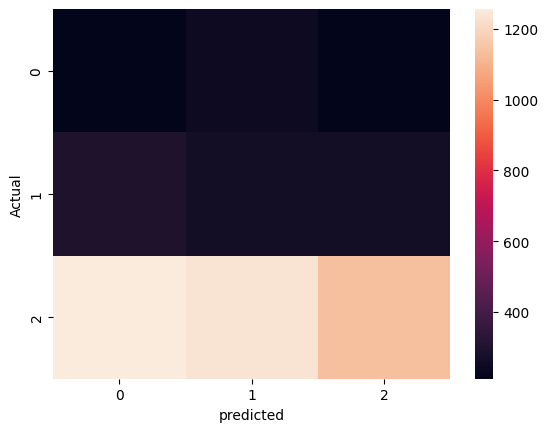

cross validation score: 
0.34750000000000003
________________________________________________________________________________
KNeighborsClassifier()
________________________________________________________________________________
              precision    recall  f1-score   support

           1       0.13      0.93      0.23       671
           2       0.15      0.04      0.06       821
           3       0.71      0.02      0.04      3623

    accuracy                           0.14      5115
   macro avg       0.33      0.33      0.11      5115
weighted avg       0.55      0.14      0.06      5115



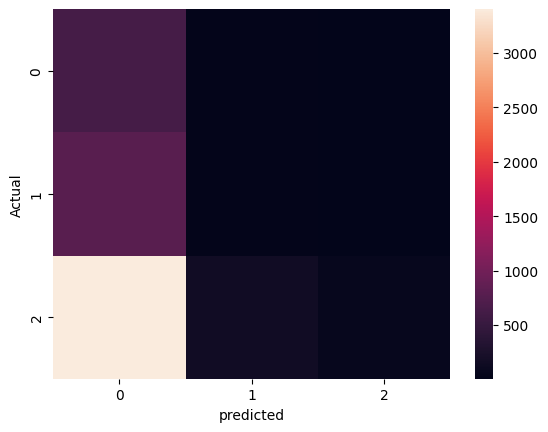

cross validation score: 
0.3378333333333333
________________________________________________________________________________
DecisionTreeClassifier(class_weight='balanced', random_state=42)
________________________________________________________________________________
              precision    recall  f1-score   support

           1       0.12      0.28      0.17       671
           2       0.15      0.32      0.21       821
           3       0.71      0.37      0.48      3623

    accuracy                           0.35      5115
   macro avg       0.33      0.32      0.29      5115
weighted avg       0.54      0.35      0.40      5115



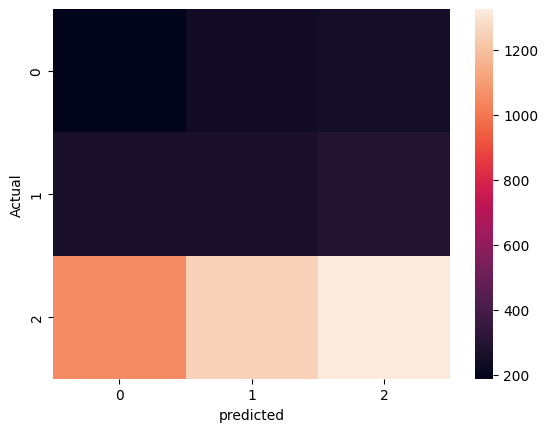

cross validation score: 
0.353
________________________________________________________________________________
GradientBoostingClassifier(random_state=42)
________________________________________________________________________________
              precision    recall  f1-score   support

           1       0.13      0.35      0.18       671
           2       0.16      0.37      0.22       821
           3       0.71      0.27      0.39      3623

    accuracy                           0.30      5115
   macro avg       0.33      0.33      0.27      5115
weighted avg       0.54      0.30      0.34      5115



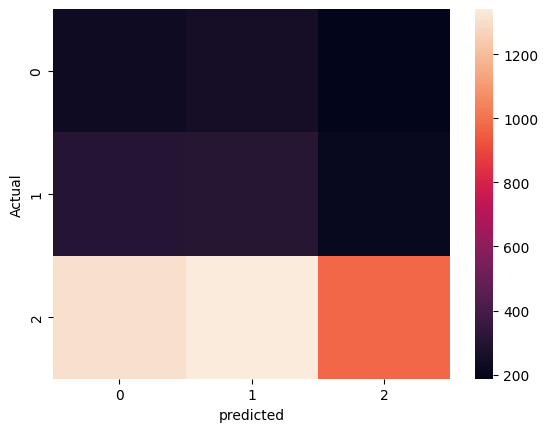

cross validation score: 
0.33866666666666667
________________________________________________________________________________
AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=1,
                                                    random_state=42),
                   random_state=42)
________________________________________________________________________________
              precision    recall  f1-score   support

           1       0.12      0.28      0.17       671
           2       0.15      0.26      0.19       821
           3       0.71      0.44      0.54      3623

    accuracy                           0.39      5115
   macro avg       0.33      0.32      0.30      5115
weighted avg       0.54      0.39      0.43      5115



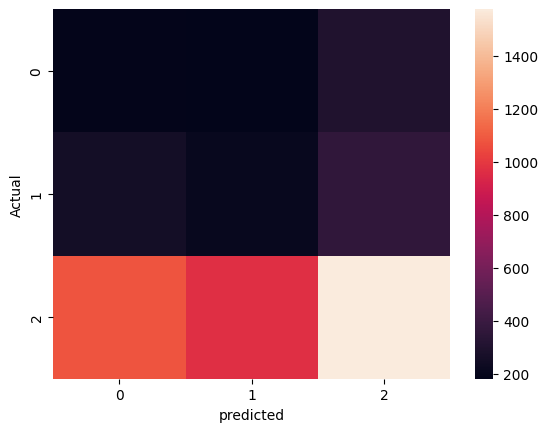

cross validation score: 
0.355
________________________________________________________________________________
RandomForestClassifier(class_weight='balanced', random_state=42)
________________________________________________________________________________
              precision    recall  f1-score   support

           1       0.13      0.27      0.17       671
           2       0.15      0.31      0.20       821
           3       0.71      0.40      0.51      3623

    accuracy                           0.37      5115
   macro avg       0.33      0.33      0.30      5115
weighted avg       0.55      0.37      0.42      5115



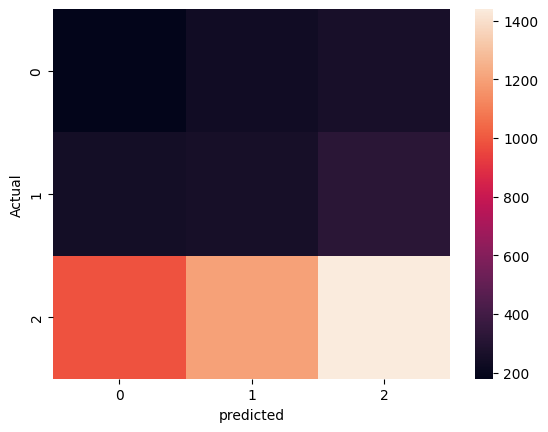

cross validation score: 
0.3496666666666666
________________________________________________________________________________
GaussianNB()
________________________________________________________________________________
              precision    recall  f1-score   support

           1       0.13      0.96      0.23       671
           2       0.14      0.02      0.03       821
           3       0.71      0.02      0.04      3623

    accuracy                           0.14      5115
   macro avg       0.33      0.33      0.10      5115
weighted avg       0.54      0.14      0.07      5115



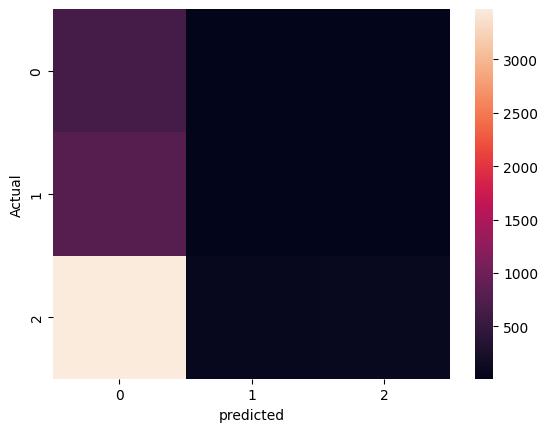

cross validation score: 
0.33266666666666667
________________________________________________________________________________


In [ ]:
models= [SVC(),KNeighborsClassifier(),DecisionTreeClassifier(random_state=42, class_weight='balanced'),GradientBoostingClassifier(random_state=42),AdaBoostClassifier(estimator=base_tree, random_state=42),RandomForestClassifier(random_state=42, class_weight='balanced'),GaussianNB()]
for model in models:
  model.fit(x_sampled,y_sampled)
  print(str(model))
  print('____'*20)
  y_pred=model.predict(test_matrix)
  print(classification_report(y_test,y_pred))
  sns.heatmap(confusion_matrix(y_test,y_pred))
  plt.xlabel('predicted')
  plt.ylabel('Actual')
  plt.show()
  print('cross validation score: ')
  print(cross_val_score(model,x_sampled,y_sampled,cv=5).mean())
  print('____'*20)

best cross validation score RandomForestClassifier is selected

**Hyperparameter tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
# RandomForestClassifier
parameter={
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}
customer_rater=RandomizedSearchCV(AdaBoostClassifier(estimator=base_tree,random_state=42),param_distributions=parameter,scoring='f1_macro',cv=5,n_iter=20,random_state=42,n_jobs=-1)
customer_rater.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5,
                   estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                 max_depth=1,
                                                                                 random_state=42),
                                                random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.5,
                                                          1.0],
                                        'n_estimators': [50, 100, 200, 300]},
                   random_state=42, scoring='f1_macro')

In [ ]:
customer_rater.best_params_

{'n_estimators': 50, 'learning_rate': 1.0}

In [ ]:
x['Session_Duration_Minutes'].unique()

array(['12.25 : 15.0', '15.0 : 17.75', '9.5 : 12.25', '17.75 : 20.5',
       '6.75 : 9.5', '20.5 : 23.25', '3.978 : 6.75', '23.25 : 26.0'],
      dtype=object)

In [ ]:
data={'Session_Duration_Minutes':x['Session_Duration_Minutes'].unique(), 'Age':x['Age'].unique(), 'Pages_Viewed': x['Pages_Viewed'].unique(), 'Total_Amount':x['Total_Amount'].unique(), 'encoder':one,'model':customer_rater}

In [ ]:
import pickle
with open("rater_pickle.pkl", "wb") as obj:
  pickle.dump(data, obj)

In [ ]:
x_train.columns

Index(['Session_Duration_Minutes', 'Age', 'Pages_Viewed', 'Total_Amount'], dtype='object')

In [ ]:
%%writefile rater_python.py
import streamlit as st
import pickle
import pandas as pd
import numpy as np
with open("rater_pickle.pkl", "rb") as obj:
  data=pickle.load(obj)
  model=data['model']
  encoder=data['encoder']
  session_list=data['Session_Duration_Minutes']
  page_list=data['Pages_Viewed']
  amount_list=data['Total_Amount']
  age_list=data['Age']

st.title('Customer Rating of Turkish online retail platform')

user_input = {
    'Session_Duration_Minutes': st.selectbox('Session Range Used (minutes)',session_list),
    'Age': st.selectbox('Customer Age Range',age_list),
    'Pages_Viewed': st.selectbox('Pages Viewed',page_list),
    'Total_Amount': st.selectbox('Month of Purchase',amount_list)
}

button=st.button('Predict Customer Rate')

if button:
  user_df = pd.DataFrame([user_input])
  user_one = encoder.transform(user_df)
  prediction = model.predict(user_one)
  st.write('Customer Rate mostly :',int(prediction[0]))


Writing rater_python.py
